Jupyter Notebook per fit ed eventuale confronto di piu set di dati diversi.

In [2]:
import sys
sys.path.append("..")

%run "../moduli.py"

In [3]:
try:
    confronto
except NameError:
    confronto = True
try:
    nonlineare
except NameError:
    nonlineare = True

In [4]:
if confronto == True:
    plot = 'confronto'
elif confronto == False:
    plot = 'singolo'
if nonlineare == True:
    mode = 'nonlineare'
elif nonlineare == False:
    mode = 'locale'

# 1. Lettura

Lettura dal file "config.json".

In [5]:
with open("nonlineare.json") as f:
    nomi = json.load(f)

keys = list(nomi["metodi"].keys())

files_input = {}
for key in keys:
    files_input[key] = os.path.join(nomi["cartella"]["input"],nomi["metodi"][key]["file_input"])

Creazione cartelle

In [6]:
os.makedirs(nomi["cartella"][mode], exist_ok=True)
for key in keys:
    os.makedirs(os.path.join(nomi["cartella"][mode], key),
                exist_ok=True
    )

Lettura file dati

In [7]:
data = {}
for key in keys:
    data[key] = {}
    dati = let.csv_to_dict(files_input[key])

    if not nonlineare:
        xdata = Misura(dati["x"][0:8],dati["sx"][0:8])
        ydata = Misura(dati["y"][0:8],dati["sy"][0:8])
    elif nonlineare:
        xdata = Misura(dati["x"],dati["sx"])
        ydata = Misura(dati["y"],dati["sy"])

    data[key]['x'] = xdata
    data[key]['y'] = ydata

# 2. Analisi

In [8]:
if not nonlineare:
    def modello(par, x):
        return par[0] + par[1]*x

    modelli = {
        'A' : modello,
        'phi' : modello
    }

    parametri_labels = {
        'A' : ['a','b'],
        'phi' : ['a','b']
    }

    beta = {
        'A' : [1, 1],
        'phi' : [1, 1]
    }

$$
A(x;\,p_0,f_{off},A_{off}) =
\frac{1}{\sqrt{1 + \left(\frac{x + p_1}{p_0}\right)^2}} + p_2
$$
$$
\phi(x;\,p_0,f_{off},\phi _{off}) =
\arctan\left(\frac{x + p_1}{p_0}\right) + p_2
$$

In [9]:
if nonlineare:
    def modello_A(par, x):
        return 1/np.sqrt(1 + ( (x + par[1]) /par[0])**2) + par[2]

    def modello_phi(par, x):
        return np.arctan( (x + par[1]) /par[0]) + par[2]

    modelli = {
        'A' : modello_A,
        'phi' : modello_phi
    }

    parametri_labels = {
        'A' : ['f_t', 'f_{off}', 'A_{off}'],
        'phi' : ['f_t', 'f_{off}', '\\phi_{off}']
    }

    beta = {
        'A' : [1000, 0, 0],
        'phi' : [1000, 0, 0]
    }

Analisi e test statistici

In [10]:
analisi = {}
residui = {}
chi_quadri = {}

risultati_fit = {}

for key in keys:

    ###########################
    ##  Lettura
    ###########################

    xdata = data[key]["x"]
    ydata = data[key]["y"]
    modello = modelli[key]
    beta0 = beta[key]

    param_labels = parametri_labels[key]
    titolo = f"{nomi['metodi'][key]['titolo']}"

    file_output1 = os.path.join(
        nomi["cartella"][mode],
        key,
        nomi["output"]["regressione"] + ".txt"
    )
    file_output2 = os.path.join(
        nomi["cartella"][mode],
        key,
        nomi["output"]["residui"] + ".txt"
    )
    file_output3 = os.path.join(
        nomi["cartella"][mode],
        key,
        nomi["output"]["chi"] + ".txt"
    )

    ###########################
    ##  Analisi
    ###########################

    anal = an.fit(xdata, ydata, modello, beta0)
    analisi[key] = anal
    let.inizializza_output(file_output1)
    let.salva_analisi(anal, param_labels, file_output1)

    ###########################
    ##  Test Statistici
    ###########################
    # Residui
    let.inizializza_output(file_output2)
    res = an.residui(xdata, ydata, anal.val, modello, file_output2, titolo)
    residui[key] = res

    # Chi
    let.inizializza_output(file_output3)
    chi = an.chi_quadro(xdata, ydata, anal.val, modello, file_output3, titolo)
    chi_quadri[key] = chi

    print(f"###### {key} ######")
    print(RisultatiFit(anal,res,chi))
    risultati_fit[key] = let.ris_fit_to_dict(RisultatiFit(anal,res,chi))

###### A ######
Parametri regressione :
5470.867520972346 ± 2.0468475028984705
121.42235808100152 ± 2.5188502011836706
0.0038508692619882924 ± 0.010797857682519103

Somma residui :
-0.0118
Somma chi quadri e chi ridotto :
0.0969
0.0075

###### phi ######
Parametri regressione :
5329.372010044143 ± 0.011971726925267517
103.37340895718347 ± 39.37290351892206
-0.027009879539734813 ± 0.007478416427234861

Somma residui :
0.5954
Somma chi quadri e chi ridotto :
55.2846
4.2527



In [11]:
gf.display_dizionario(risultati_fit)
let.esporta_pickle(risultati_fit, filename = f"{mode}.pkl")

# 3. Grafici

## Regressione

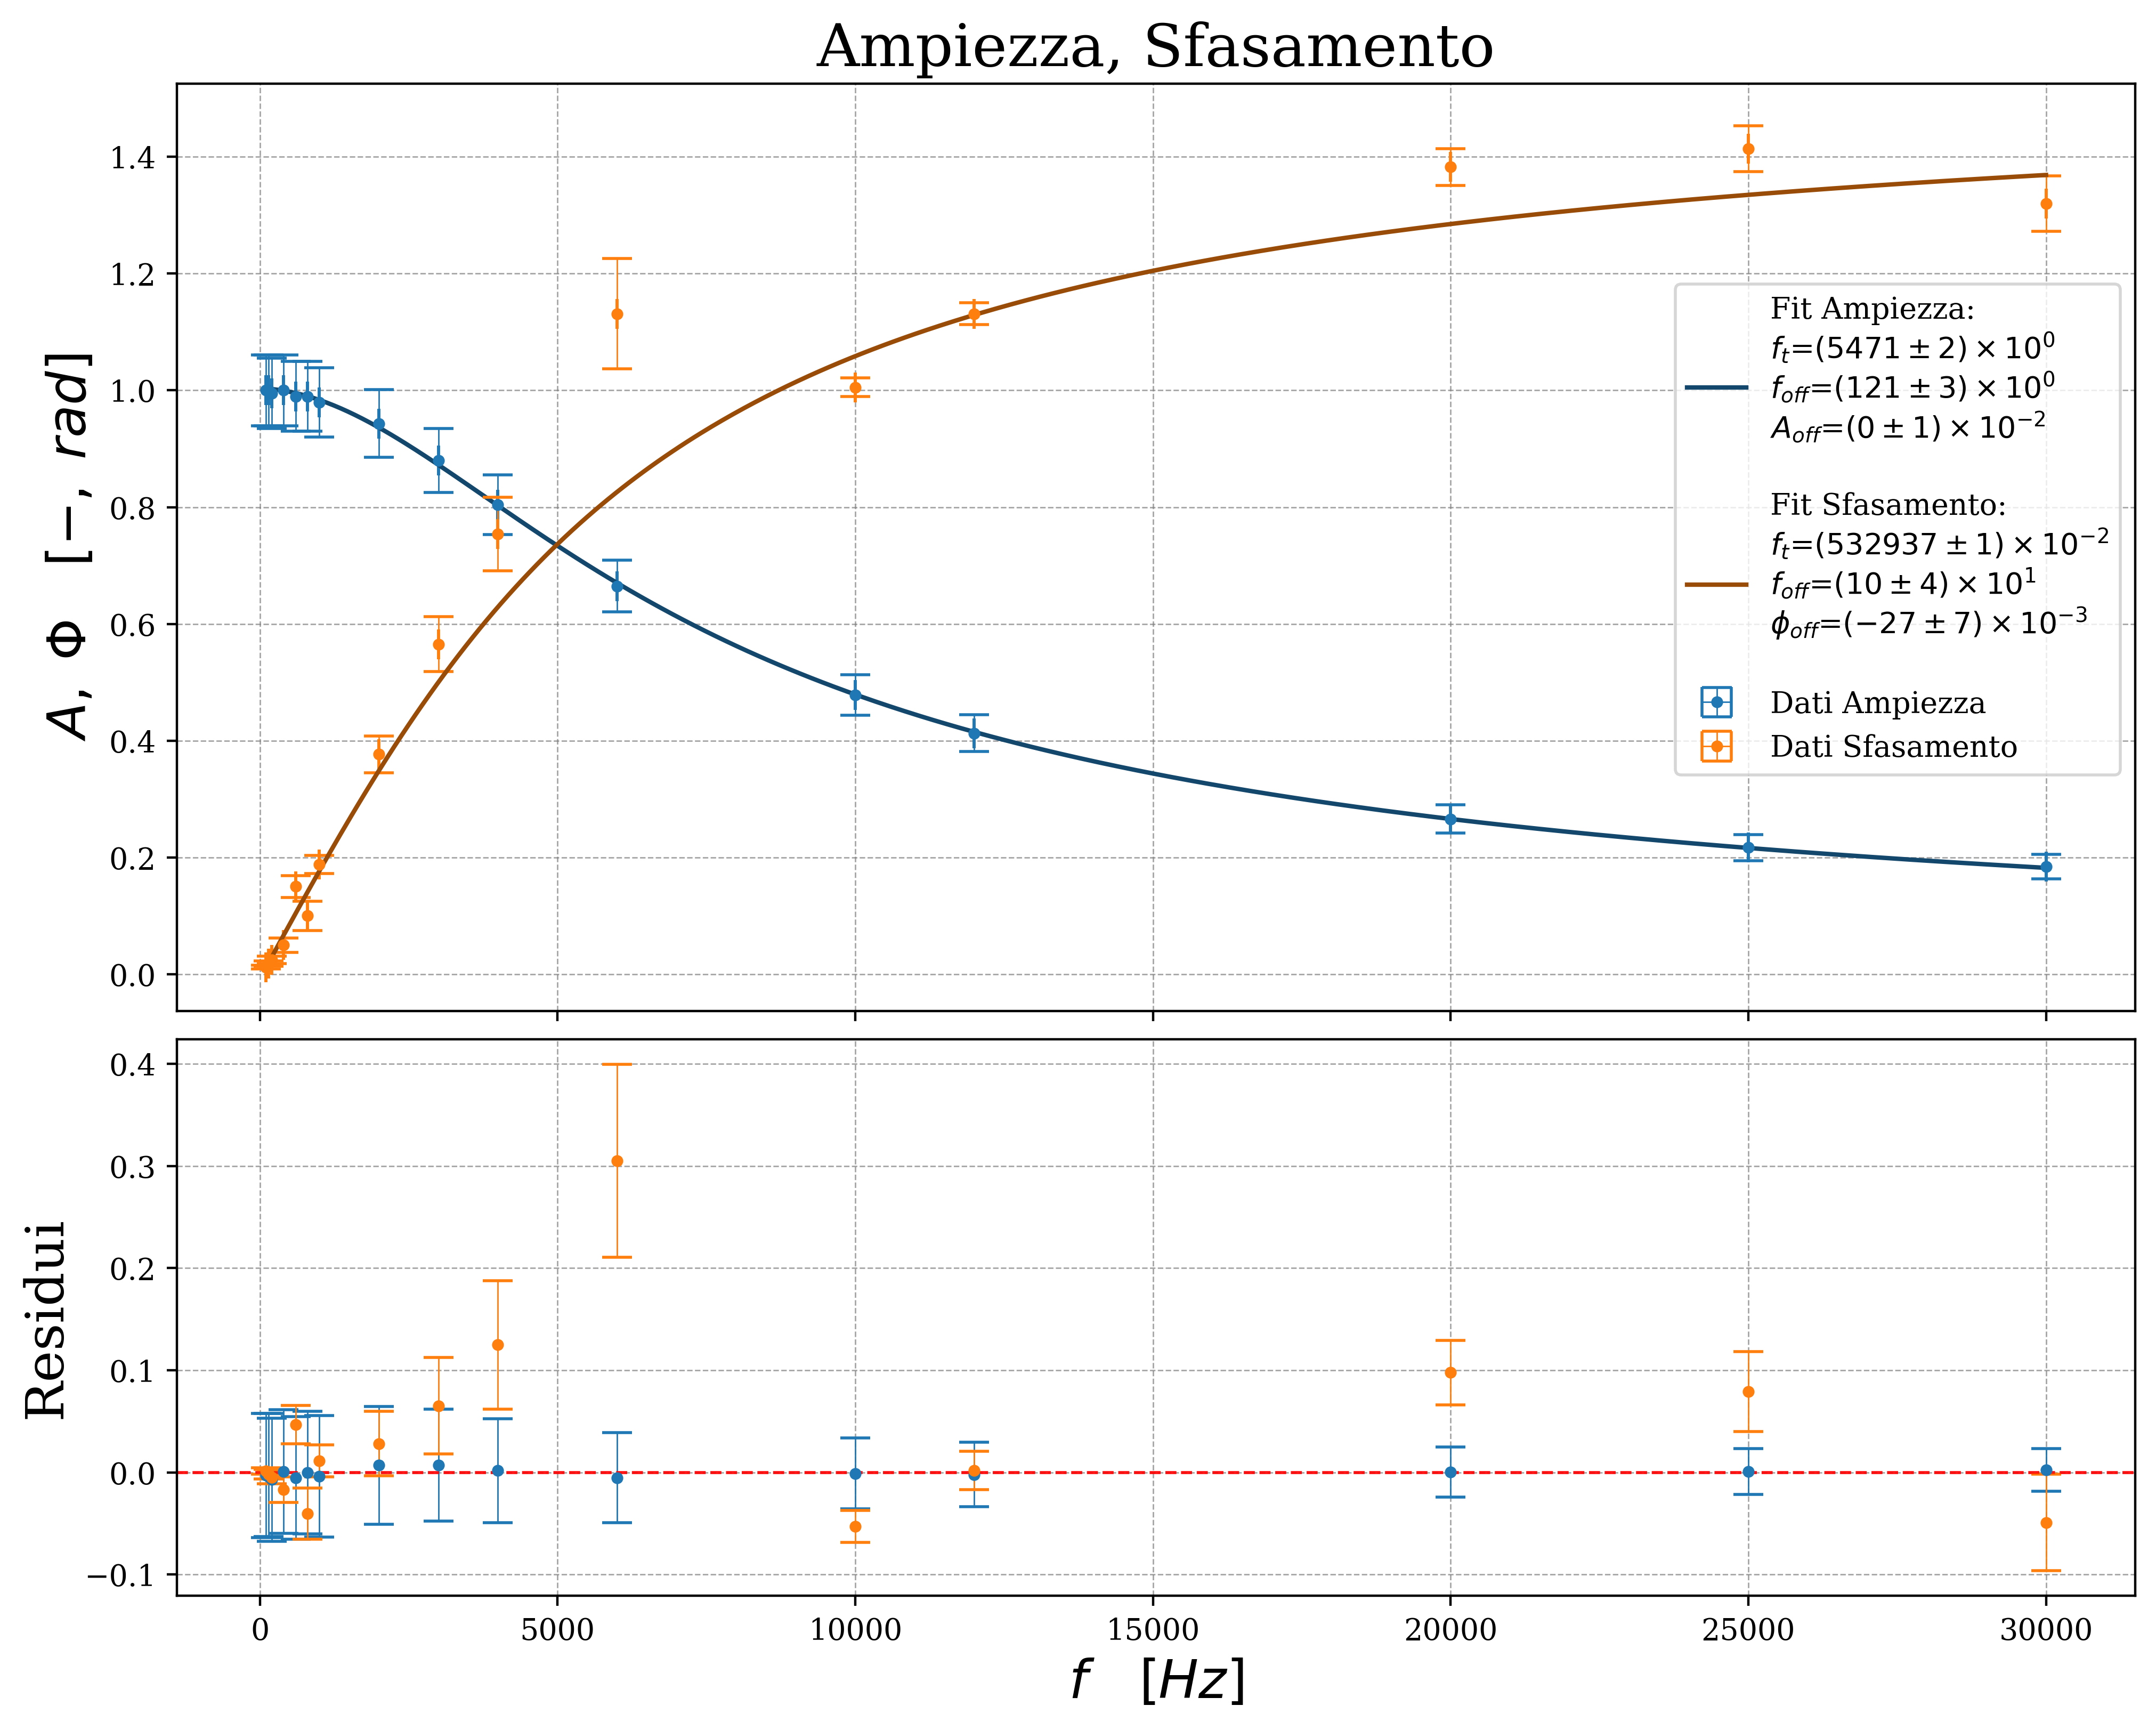

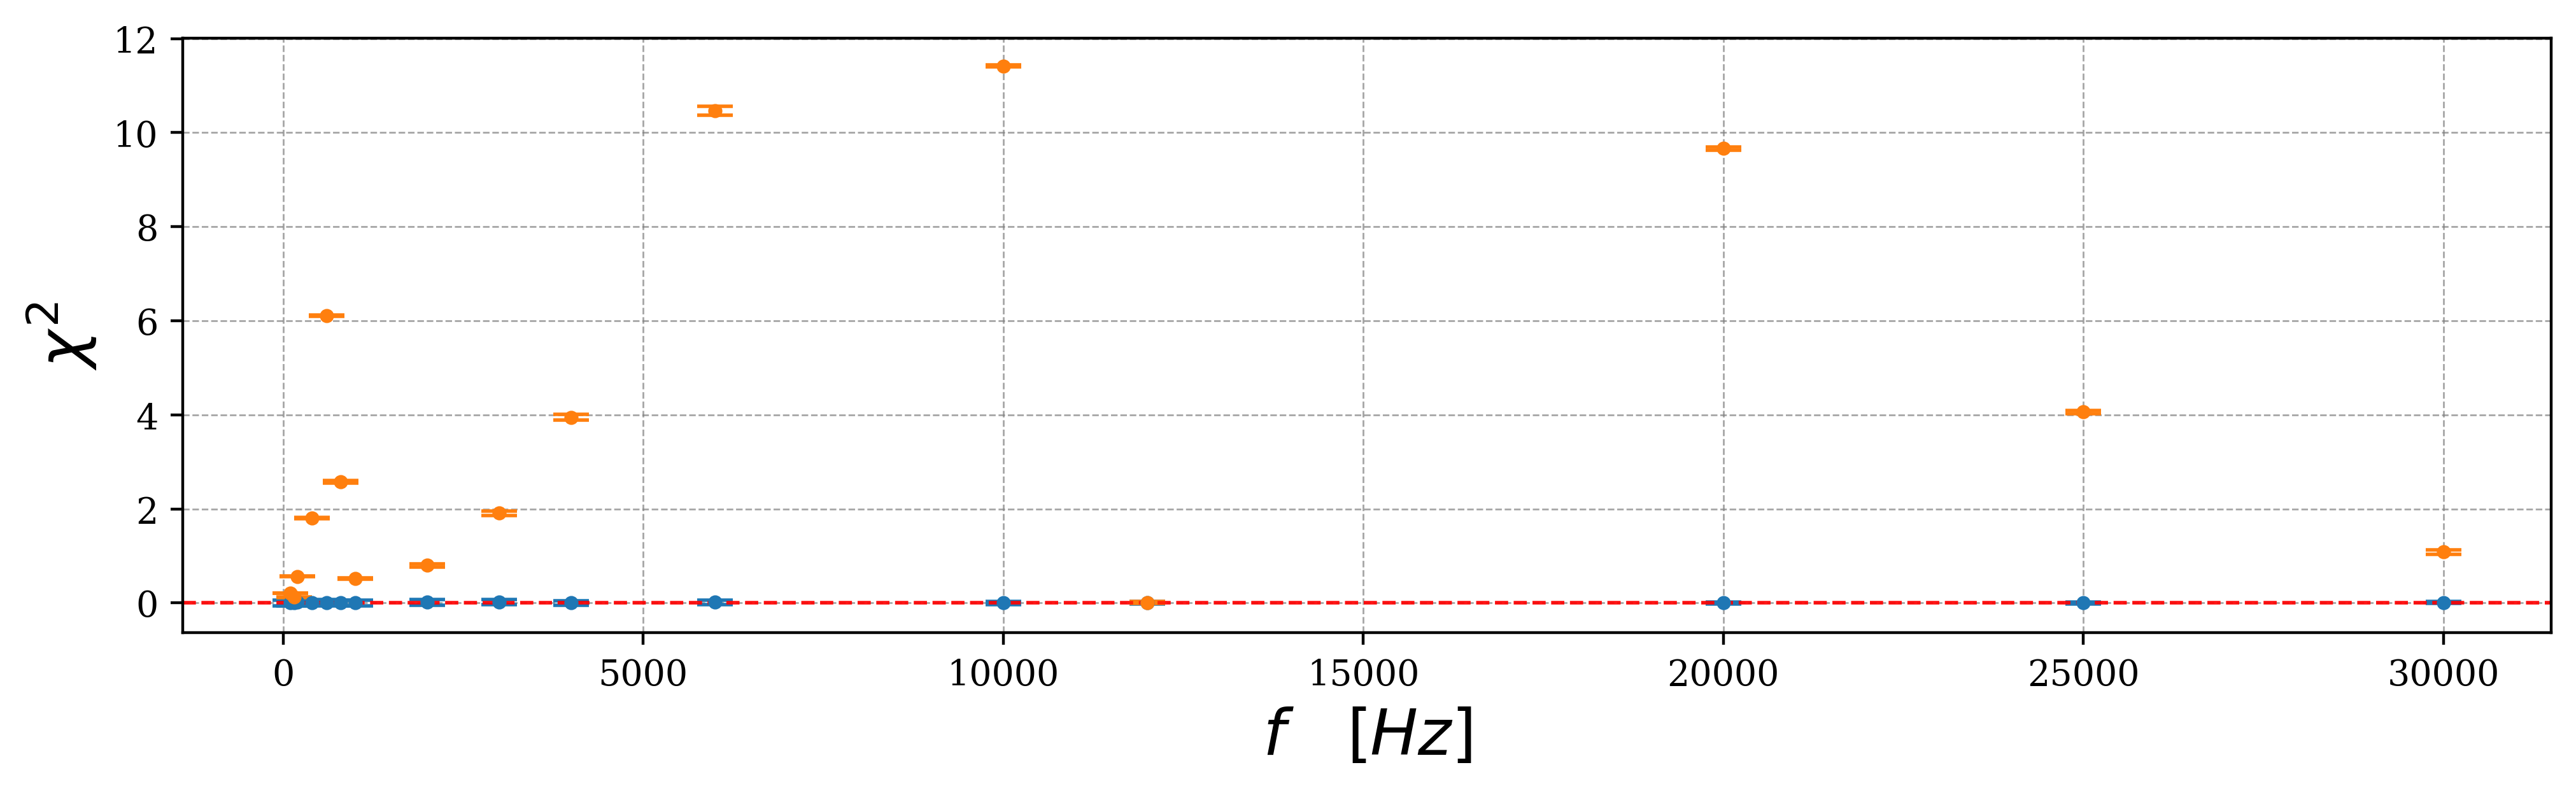

In [ ]:
if confronto:

    key = keys[0]
    titolo = rf"{nomi['metodi'][keys[0]]['titolo']}" + "".join(rf", {nomi['metodi'][keys[i+1]]['titolo']}" for i in range(len(keys)-1))
    xlabel = f"{nomi['metodi'][key]['xlabel']}"
    xunit = f"{nomi['metodi'][key]['xunit']}"
    ylabel = rf"{nomi['metodi'][keys[0]]['ylabel']}" + "".join(rf",\;{nomi['metodi'][keys[i+1]]['ylabel']}" for i in range(len(keys)-1))
    yunit = rf"{nomi['metodi'][keys[0]]['yunit']}" + "".join(rf",\;{nomi['metodi'][keys[i+1]]['yunit']}" for i in range(len(keys)-1))

    file_output1 = os.path.join(
        nomi["cartella"][mode],
        nomi["output"]["regressione"] + "_confronto.pdf"
    )
    file_output2 = os.path.join(
        nomi["cartella"][mode],
        nomi["output"]["chi"] + "_confronto.pdf"
    )

    # Inizializzazione e labels
    fig1, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(10, 8),
        gridspec_kw={'height_ratios': [5, 3]},
        constrained_layout=True,
        sharex=True
    )
    ax1.tick_params(axis='x', labelbottom=False)
    gf.parametri_grafico(ax1, f"{titolo}", ylabel= rf"${ylabel}\quad [{yunit}]$")
    gf.parametri_grafico(ax2, xlabel=rf"${xlabel}\quad [{xunit}]$", ylabel="Residui")

    fig2,ax = plt.subplots(1, 1,  figsize=(10, 3), constrained_layout = True)
    gf.parametri_grafico(ax, xlabel=rf"${xlabel}\quad [{xunit}]$", ylabel=r"$\chi^2$")

    for j,key in enumerate(keys):

        ###########################
        ##  Lettura
        ###########################

        xdata = data[key]["x"]
        ydata =  data[key]["y"]
        anal = analisi[key]
        modello = modelli[key]
        res = residui[key]
        chi = chi_quadri[key]

        param_labels = parametri_labels[key]

        ###########################
        ##  Plotting Regressione
        ###########################

        # Dati
        ax1.errorbar(
            xdata.val,
            ydata.val,
            xerr=xdata.s,
            yerr=ydata.s,
            label=rf"Dati {nomi['metodi'][keys[j]]['titolo']}",
            **gf.errorbar_params,
            color = gf.colori[j]
        )

        # Fit
        fit_label = rf"Fit {nomi['metodi'][keys[j]]['titolo']}:" + "\n" + "".join(f"${param_labels[i]}$=${gf.formatta_errore(anal.val[i],anal.s[i])}$\n"  for i in range(len(param_labels)))
        x_fit = np.linspace(min(xdata.val), max(xdata.val), 500)
        ax1.plot(
            x_fit,
            modello(anal.val,x_fit),
            label=fit_label,
            **gf.plot_params,
            color = gf.darken(gf.colori[j])
        )

        #ax1.legend()
        ax1.legend(loc='upper right', bbox_to_anchor=(1, 0.8), fontsize='medium')

        # Residui
        ax2.errorbar(
            res[0],
            res[1],
            yerr=res[2],
            **gf.errorbar_params,
            color=gf.colori[j]
        )
        # Linea orizzontale
        ax2.axhline(
            0,
            **gf.line_params,
            color="red"
        )

        ###########################
        ##  Plotting Chi Quadri
        ###########################

        # Chi Quadri
        ax.errorbar(
            chi[0],
            chi[1],
            yerr=chi[2],
            **gf.errorbar_params,
            color=gf.colori[j]
        )

        # Linea orizzontale
        ax.axhline(
            0,
            **gf.line_params,
            color="red"
        )

    let.salva_grafico(fig1,file_output1)
    let.salva_grafico(fig2, file_output2)

In [13]:
if not confronto:
    for key in keys:

        ###########################
        ##  Lettura
        ###########################

        xdata = data[key]["x"]
        ydata =  data[key]["y"]
        anal = analisi[key]
        modello = modelli[key]
        res = residui[key]
        chi = chi_quadri[key]

        param_labels = parametri_labels[key]
        titolo = f"{nomi['metodi'][key]['titolo']}"
        xlabel = f"{nomi['metodi'][key]['xlabel']}"
        xunit = f"{nomi['metodi'][key]['xunit']}"
        ylabel = f"{nomi['metodi'][key]['ylabel']}"
        yunit = f"{nomi['metodi'][key]['yunit']}"

        file_output1 = os.path.join(
            nomi["cartella"][mode],
            key,
            nomi["output"]["regressione"] + ".jpg"
        )
        file_output2 = os.path.join(
            nomi["cartella"][mode],
            key,
            nomi["output"]["chi"] + ".jpg"
        )

        # Inizializzazione e labels
        fig1, (ax1, ax2) = plt.subplots(
            2, 1,
            figsize=(10, 8),
            gridspec_kw={'height_ratios': [5, 3]},
            constrained_layout=True,
            sharex=True
        )
        ax1.tick_params(axis='x', labelbottom=False)
        gf.parametri_grafico(ax1, f"{titolo}", ylabel= rf"${ylabel}\quad [{yunit}]$")
        gf.parametri_grafico(ax2, xlabel=rf"${xlabel}\quad [{xunit}]$", ylabel="Residui")

        fig2,ax = plt.subplots(1, 1,  figsize=(10, 3), constrained_layout = True)
        gf.parametri_grafico(ax, xlabel=rf"${xlabel}\quad [{xunit}]$", ylabel=r"$\chi^2$")

        ###########################
        ##  Plotting Regressione
        ###########################

        # Dati
        ax1.errorbar(
            xdata.val,
            ydata.val,
            xerr=xdata.s,
            yerr=ydata.s,
            label="Dati",
            **gf.errorbar_params,
            color = gf.colori[0]
        )

        # Fit
        fit_label = "Fit: " + "".join(f"{param_labels[i]}=${gf.formatta_errore(anal.val[i],anal.s[i])}$\n" for i in range(len(param_labels)))
        x_fit = np.linspace(min(xdata.val), max(xdata.val), 500)
        ax1.plot(
            x_fit,
            modello(anal.val,x_fit),
            label=fit_label,
            **gf.plot_params,
            color = gf.colori[1]
        )

        #ax1.legend()
        ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))

        # Residui
        ax2.errorbar(
            res[0],
            res[1],
            yerr=res[2],
            **gf.errorbar_params,
            color=gf.colori[0]
        )
        # Linea orizzontale
        ax2.axhline(
            0,
            **gf.line_params,
            color="red"
        )

        ###########################
        ##  Plotting Chi Quadri
        ###########################

        # Chi Quadri
        ax.errorbar(
            chi[0],
            chi[1],
            yerr=chi[2],
            **gf.errorbar_params,
            color=gf.colori[0]
        )

        # Linea orizzontale
        ax.axhline(
            0,
            **gf.line_params,
            color="red"
        )

        let.salva_grafico(fig1,file_output1)
        let.salva_grafico(fig2, file_output2)